In [1]:
import ehr_utils
import shap
import os
import pickle
import matplotlib.pyplot as plt

In [ ]:
# 加载shap值

def load_or_compute_shap_values(model_name='XGBoost_0.70.pkl', type='train'):
    """
    从文件加载训练集或测试集shap值，如果文件不存在则重新计算并保存。
    
    - model_name: str, 模型文件名
    - type: str, 'train' 或 'test'，指定加载训练集或测试集的SHAP值
    
    - 返回: shap值数组
    """
    if type == 'train':
        file_path = 'shap_values_train.pkl'
    elif type == 'test':
        file_path = 'shap_values_test.pkl'
    else:
        raise ValueError("type must be either 'train' or 'test'")
    if os.path.exists(file_path):
        with open(file_path, 'rb') as f:
            shap_values = pickle.load(f)
        print(f'从文件中读取{type}集的SHAP值')
    else:
        print(f'没有找到{type}集的SHAP值文件，重新计算SHAP值...')
        data_file_path = 'data_cleaned/ver-noelectrolyte-logtransform_mean.csv'
        model_path = f'trained_models_opt/mean/{model_name}'
        model = ehr_utils.load_model(model_path)
        X_train, X_test, _, _ = ehr_utils.get_train_test(data_file_path)
        explainer_tree = shap.TreeExplainer(model)
        shap_values = explainer_tree(X_train if type == 'train' else X_test)
        with open(file_path, 'wb') as f:
            pickle.dump(shap_values, f)
        print(f'已计算并保存{type}集的SHAP值到文件 {file_path}')
    return shap_values


shap_values_train = load_or_compute_shap_values(model_name='XGBoost_0.70.pkl', type='train')
shap_values_test = load_or_compute_shap_values(model_name='XGBoost_0.70.pkl', type='test')

In [ ]:
# 自定义色系
import matplotlib.colors as mcolors
colors = ["#f11712","#0099f7", ]  # 从深蓝色到浅红色
# 创建自定义颜色映射
cmap = mcolors.LinearSegmentedColormap.from_list("custom", colors)

宏观分析

正在绘制SHAP值的蜂群图...


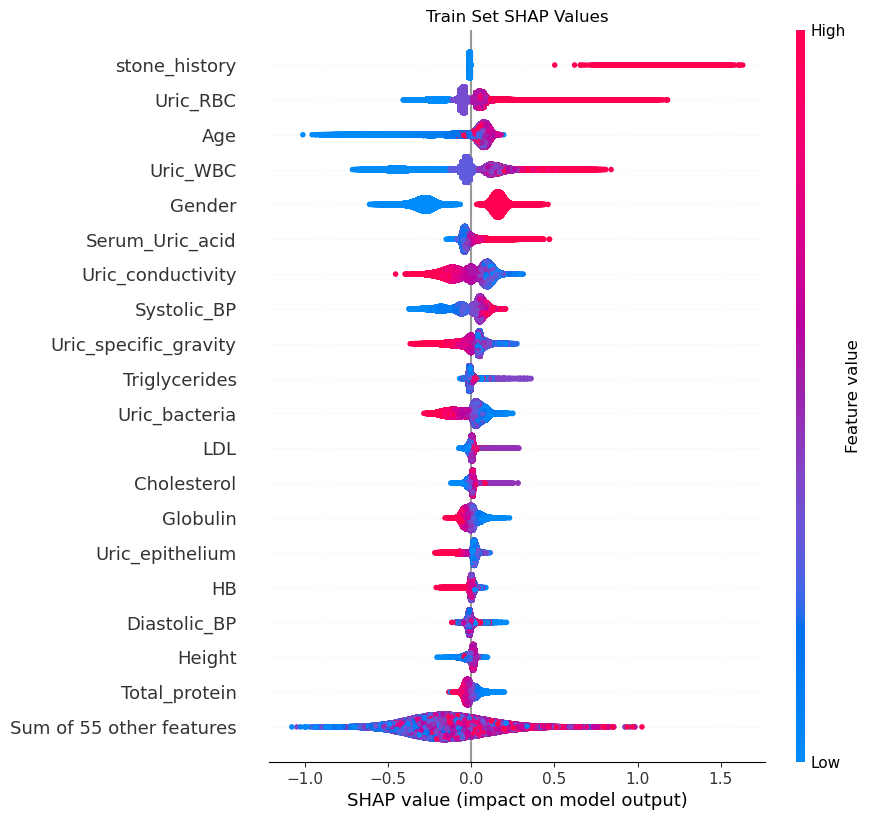

正在绘制SHAP值的蜂群图...


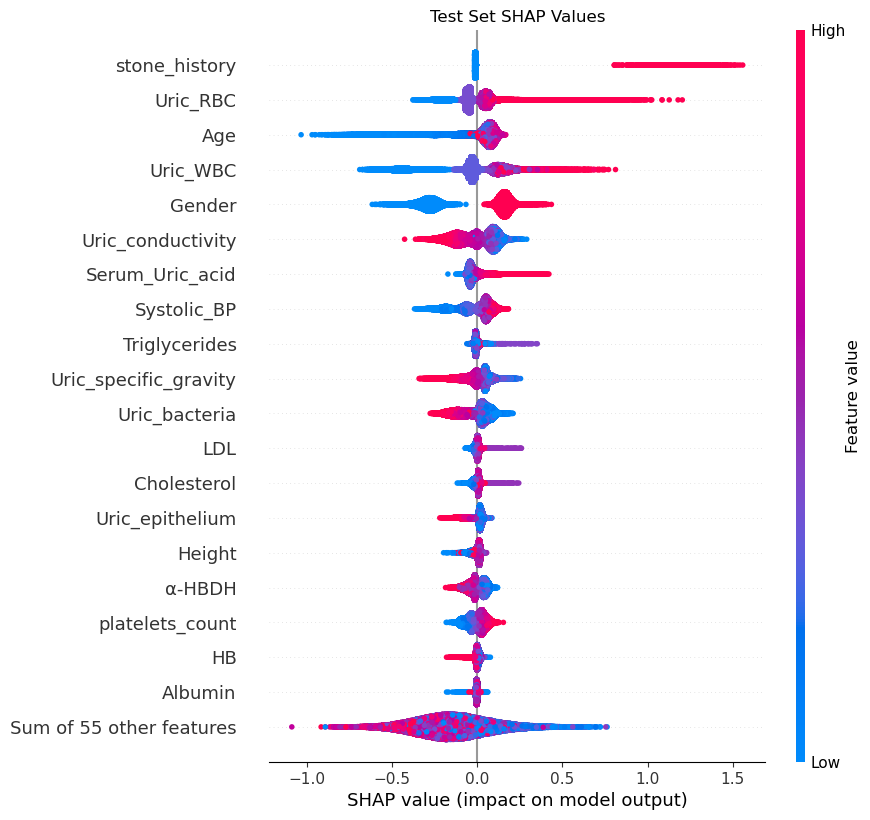

In [24]:
# 蜂群图
from shap import Explanation


def plot_beeswarm(shap_values, type='train', max_display=20, model_name='xgb'):
    """
    绘制训练集和测试集SHAP值的蜂群图。

    - shap_values: shap值数组
    - type: str, 'train' 或 'test'，指定绘制训练集或测试集的SHAP值
    - model_name: str, 模型名称，用于保存图像文件
    """
    print('正在绘制SHAP值的蜂群图...')
    fig, axs = plt.subplots(1, 1)
    plt.sca(axs)  # 将第一个轴设置为当前活跃轴
    shap.plots.beeswarm(shap_values, max_display=max_display, show=False, order=Explanation.abs.max(0))
    axs.set_title(f'{type.capitalize()} Set SHAP Values')
    # plt.tight_layout()
    os.makedirs('result_shap', exist_ok=True)
    fig.savefig(f'result_shap/shap_beeswarm_{type}_{model_name}.png', dpi=300)
    plt.show()


plot_beeswarm(shap_values_train, type='train', model_name='xgb')
plot_beeswarm(shap_values_test, type='test', model_name='xgb')

正在绘制SHAP值的条形图...


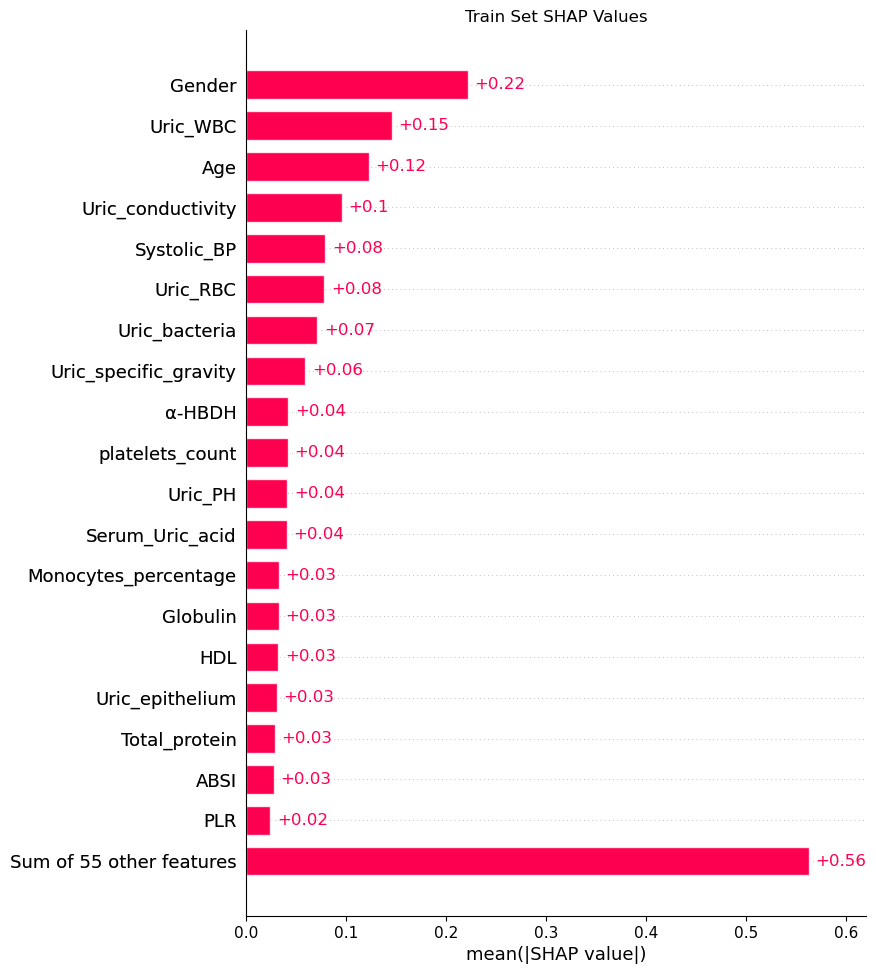

正在绘制SHAP值的条形图...


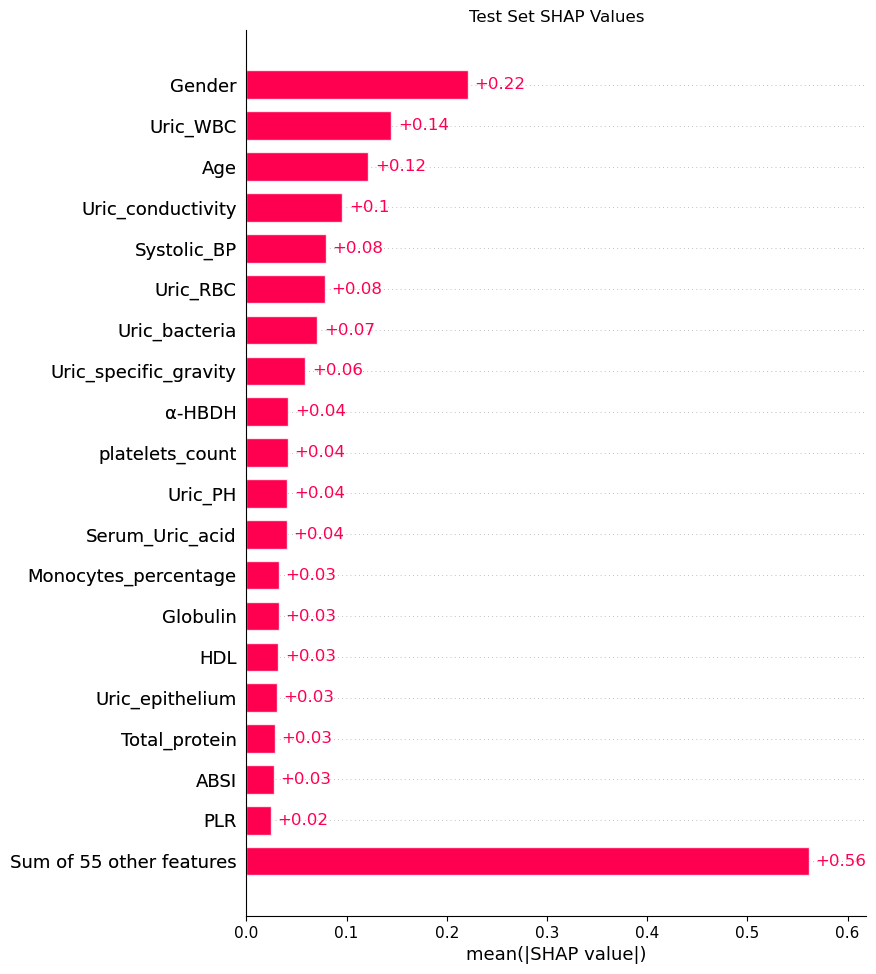

In [23]:
# 条形图
def plot_bar(shap_values, type='train', max_display=20, model_name='xgb'):
    """
    绘制训练集和测试集SHAP值的条形图。

    - shap_values: shap值数组
    - type: str, 'train' 或 'test'，指定绘制训练集或测试集的SHAP值
    - model_name: str, 模型名称，用于保存图像文件
    """
    print('正在绘制SHAP值的条形图...')
    fig, axs = plt.subplots(1, 1)
    plt.sca(axs)  # 将第一个轴设置为当前活跃轴
    shap.plots.bar(shap_values, max_display=max_display, show=False)
    axs.set_title(f'{type.capitalize()} Set SHAP Values')
    # plt.tight_layout()
    os.makedirs('result_shap', exist_ok=True)
    fig.savefig(f'result_shap/shap_bar_{type}_{model_name}.png', dpi=300)
    plt.show()


plot_bar(shap_values_train, type='train', model_name='xgb')
plot_bar(shap_values_test, type='test', model_name='xgb')

正在绘制SHAP值的蜂群图...


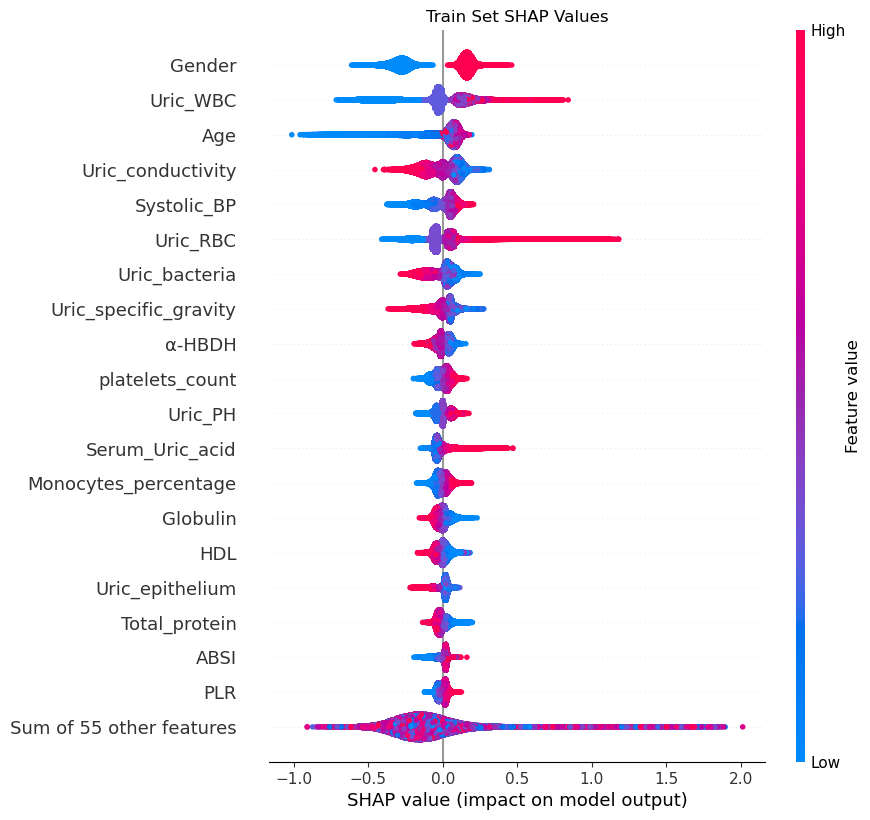

正在绘制SHAP值的蜂群图...


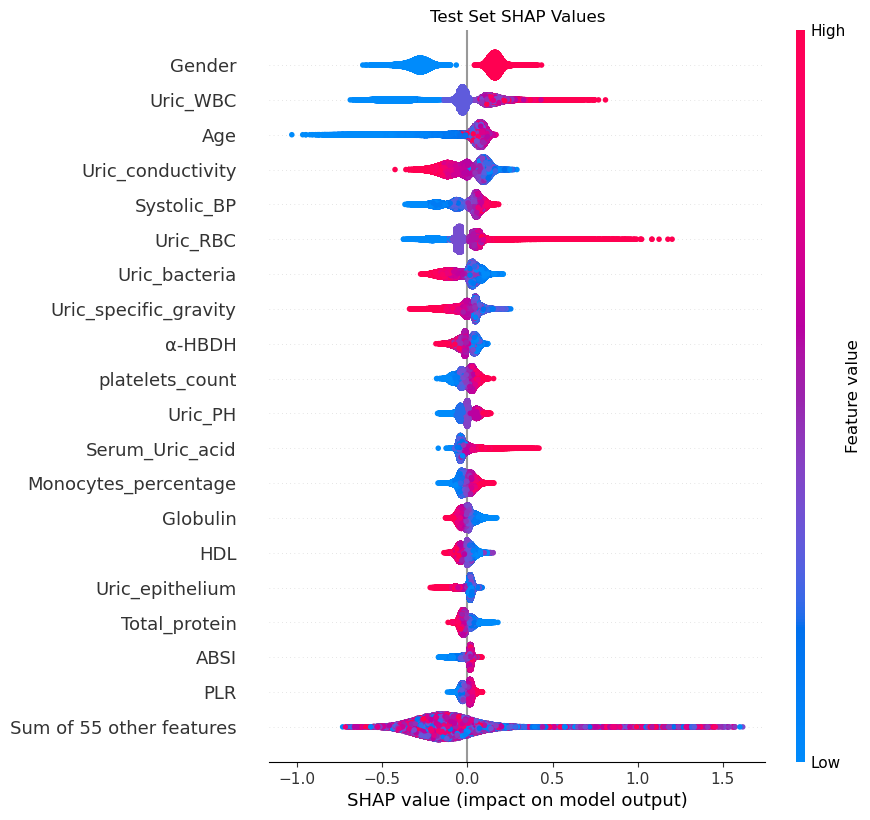

没有找到test集的SHAP值文件，重新计算SHAP值...


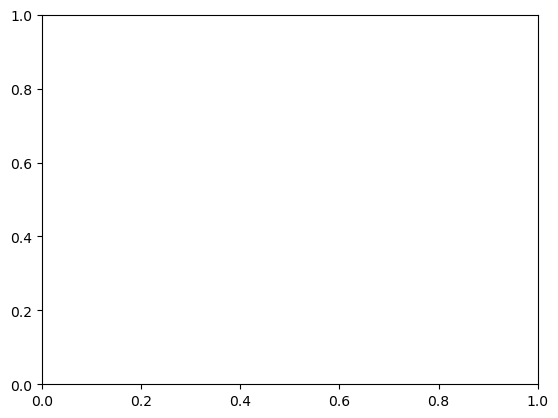

In [ ]:

# axs_beeswarm = shap.plots.beeswarm(shap_values_train, max_display=20, show=False)
# fig_beeswarm.suptitle('XGB SHAP Values on Train-Set', fontsize=16)
# fig_beeswarm.savefig('shap_beeswarm_train.png', dpi=300, bbox_inches='tight')

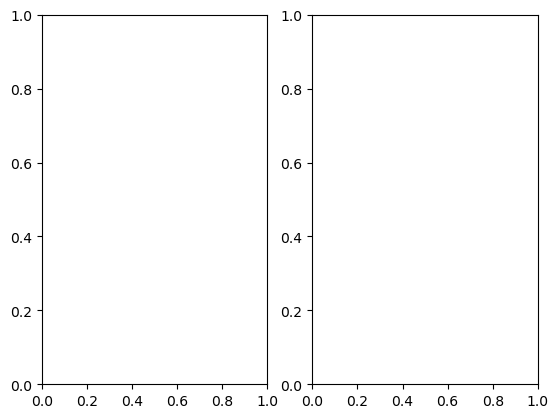

In [6]:
fig_beeswarm, axs_beeswarm = plt.subplots(1, 2)

In [ ]:
fig_beeswarm, axs_beeswarm = plt.subplots(1, 1)
axs_beeswarm = shap.plots.beeswarm(shap_values_train, max_display=20, show=False)
fig_beeswarm.suptitle('XGB SHAP Values on Train-Set', fontsize=16)
fig_beeswarm.savefig('shap_beeswarm_train.png', dpi=300, bbox_inches='tight')


def custom_shap_plot(shap_values, max_display=20, cmap=cmap, titlename='title', fig_type='bar'):
    s=['bar','beeswarm',]
    """
    自定义SHAP值可视化函数,绘图并保存图像到results_shap目录下
    
    - shap_values: SHAP值数组
    - max_display: 显示的最大特征数量
    - cmap: 自定义颜色映射
    - titlename: 图像标题
    - fig_type: SHAP图像类型，默认为'bar',可选有bar 、
    """
    fig, ax = plt.subplots()
    shap.summary_plot(shap_values, show=False, max_display=max_display, plot_type='bar', color=cmap)
    fig.suptitle(titlename, fontsize=16)
    return fig

<Axes: xlabel='mean(|SHAP value|)'>

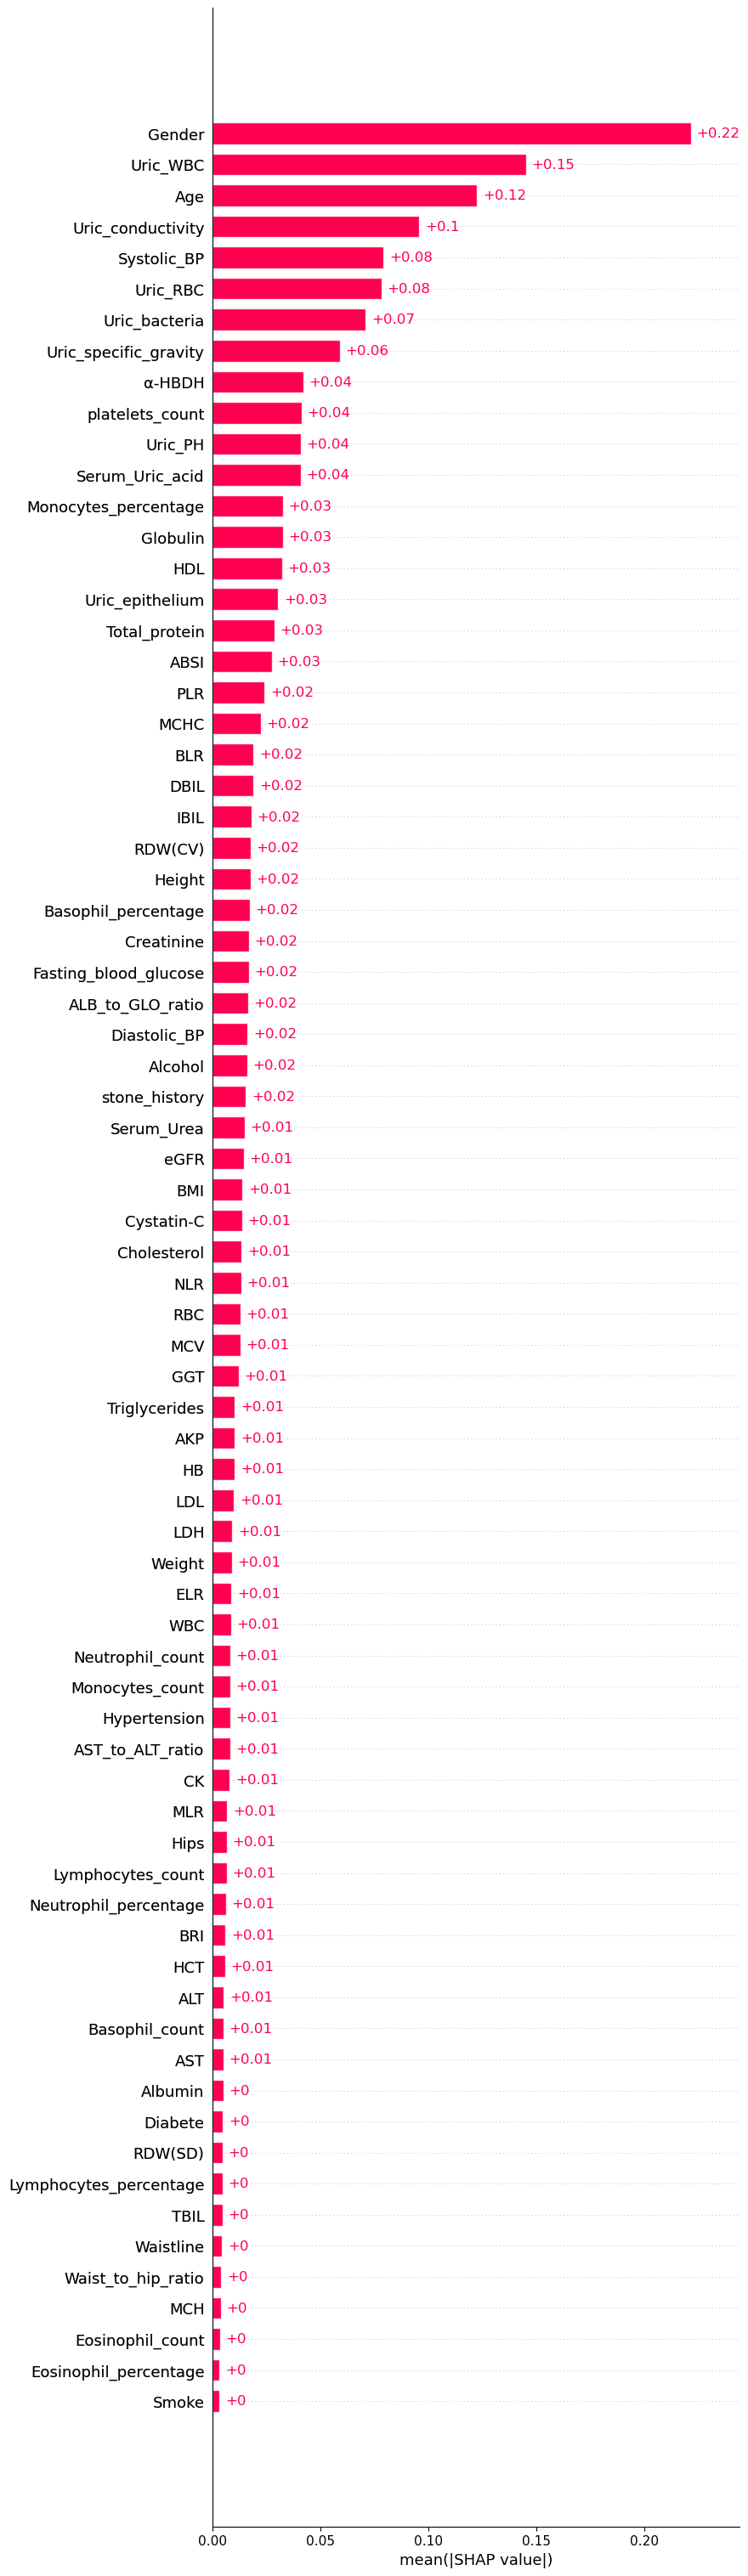

In [ ]:
# 全局条形图
shap.plots.bar(shap_values_train, max_display=len(X_train.columns), show=False)

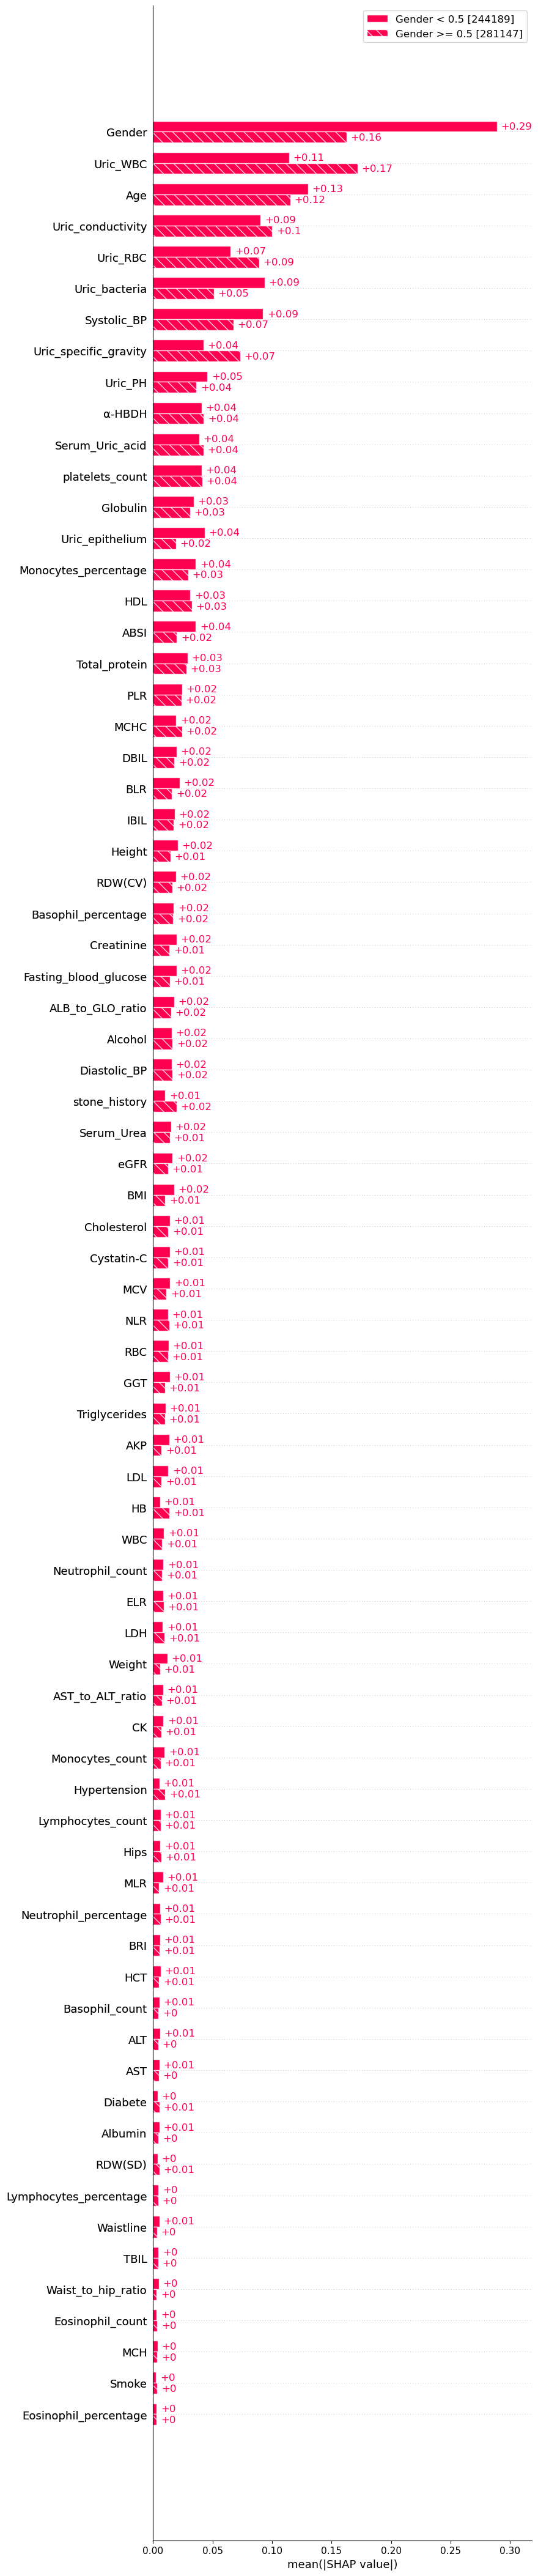

In [76]:
# 分类条形图,自动根绝区别最大的特征为2个队列显示
shap.plots.bar(shap_values_train.cohorts(2).abs.mean(0),max_display=len(X_train.columns))

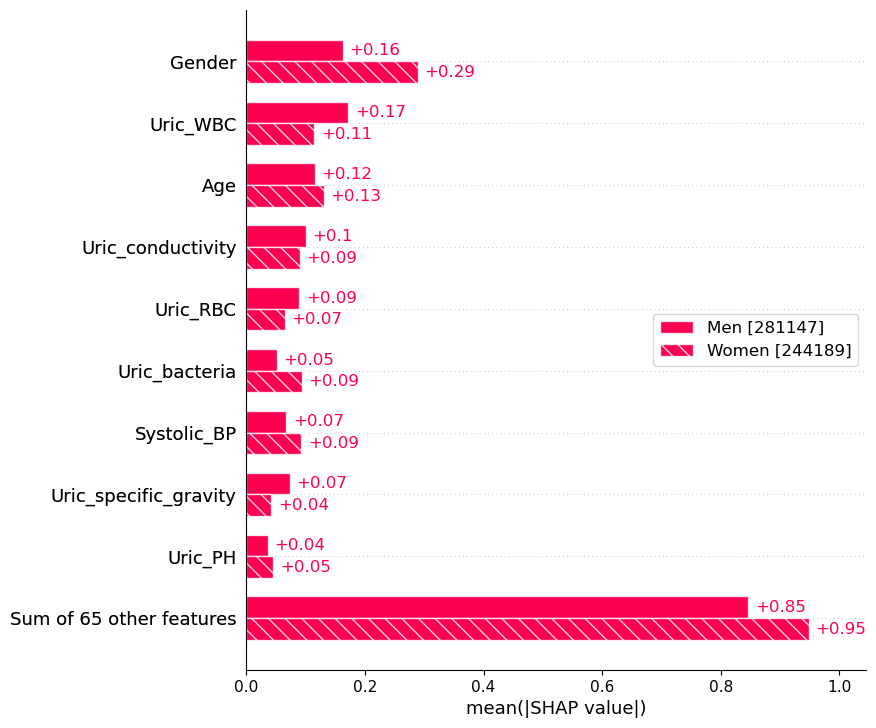

In [ ]:
#手动分类
sex = ["Women" if shap_values_train[i, "Gender"].data == 0 else "Men" for i in range(shap_values_train.shape[0])]
shap.plots.bar(shap_values_train.cohorts(sex).abs.mean(0))

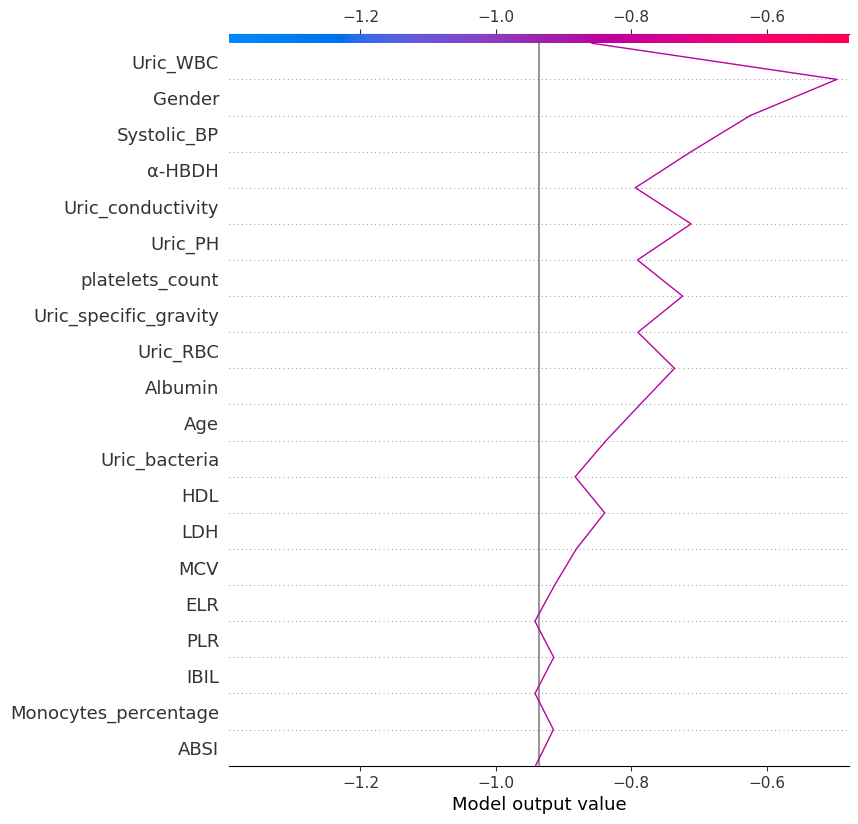

In [ ]:
# 决策图，单个样本 
# 决策图可以去观察一个正确样本 和错误样本的区别，错误样本可以使用虚线， 正确样本用实线。
expected_value = explainer_tree.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[0]
expected_value
shap.decision_plot(expected_value, shap_values_train.values[:1],X_train.columns)

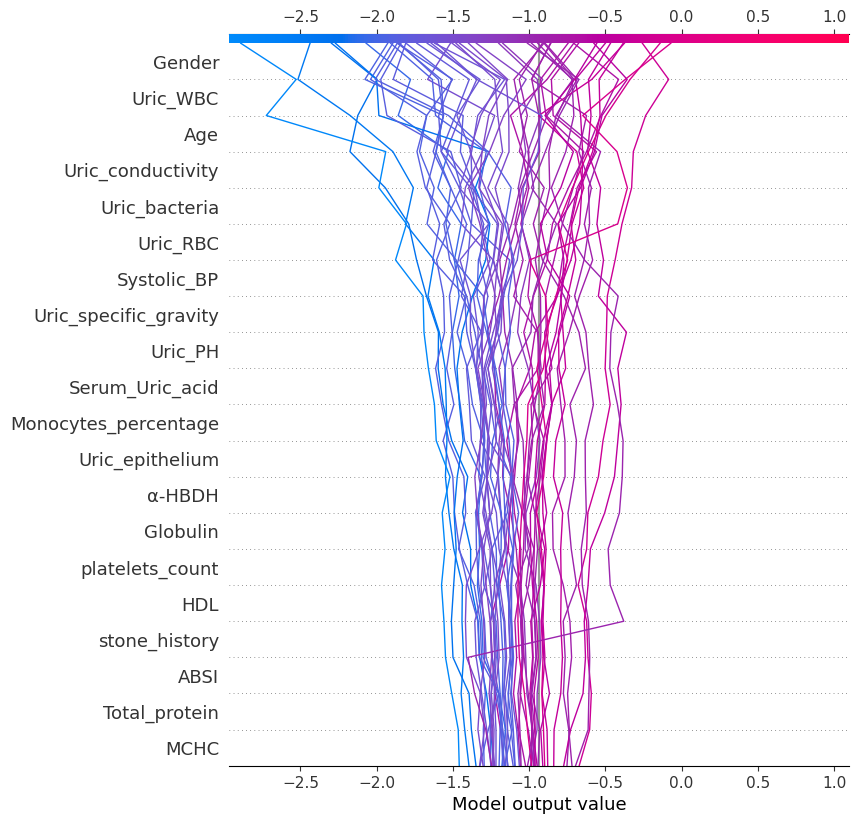

In [ ]:
# 决策图，多个样本
expected_value = explainer_tree.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[0]
expected_value
shap.decision_plot(expected_value, shap_values_train.values[:50],X_train.columns)

-0.93642473

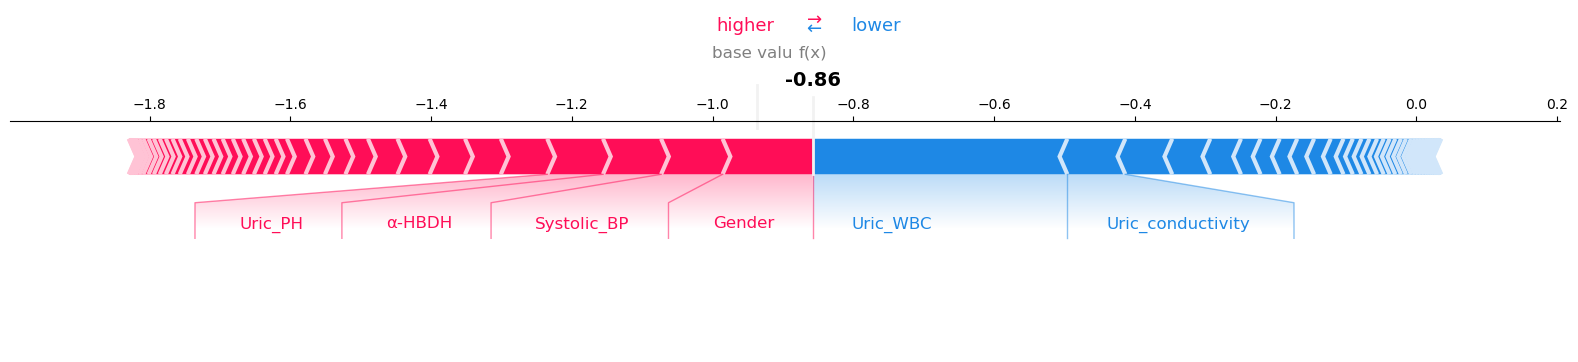

In [ ]:
#单个样本的特征贡献图
shap.force_plot(expected_value, shap_values_train.values[:1], X_train.columns, matplotlib=True)

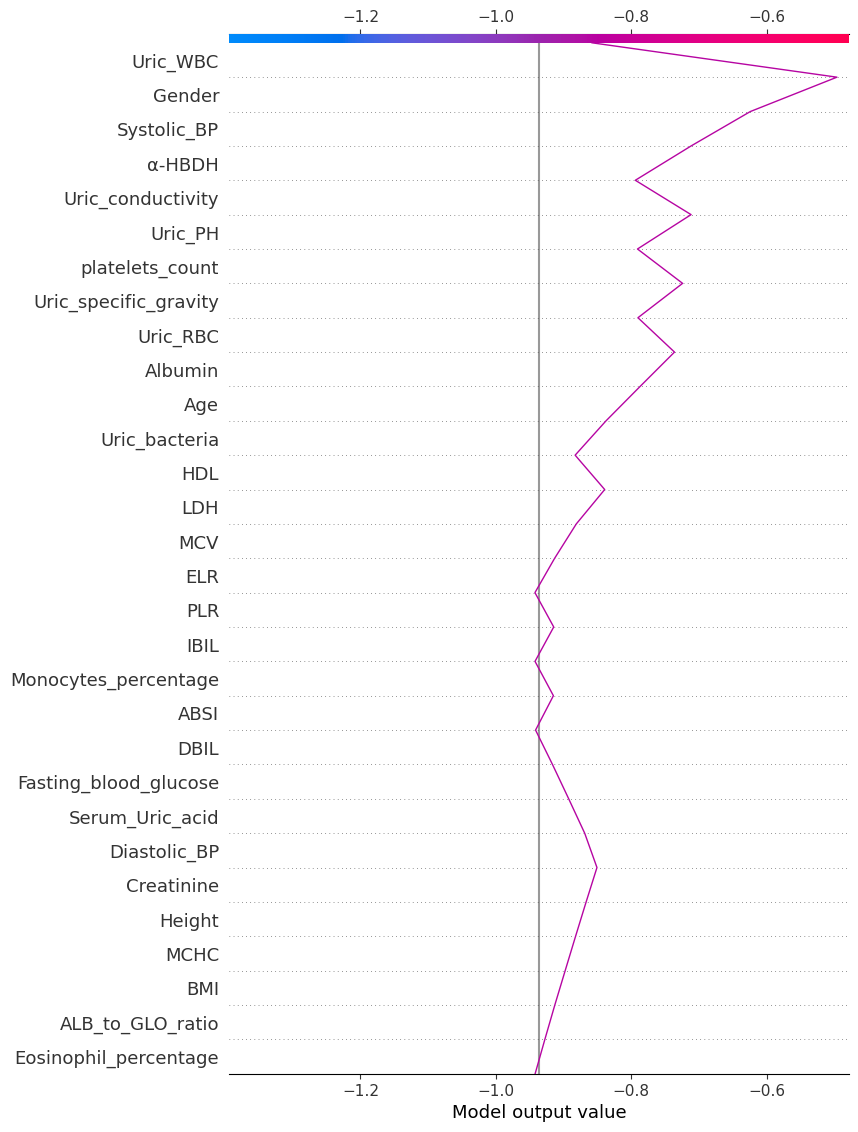

In [83]:
shap.decision_plot(expected_value, shap_values_train.values[:1], X_train.columns, feature_display_range=slice(None, -31, -1))

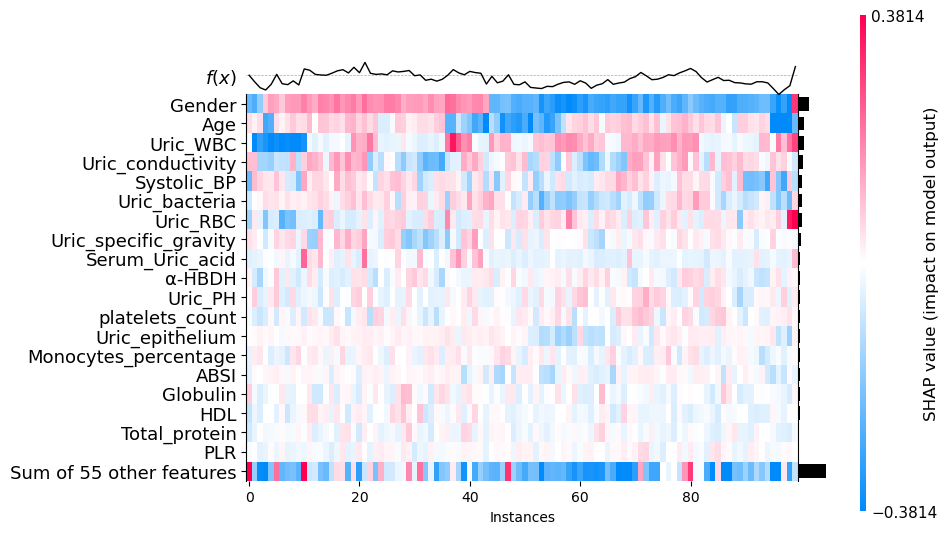

<Axes: xlabel='Instances'>

In [91]:
# https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/heatmap.html
# 热图
shap.plots.heatmap(shap_values_train[:100],max_display=20)

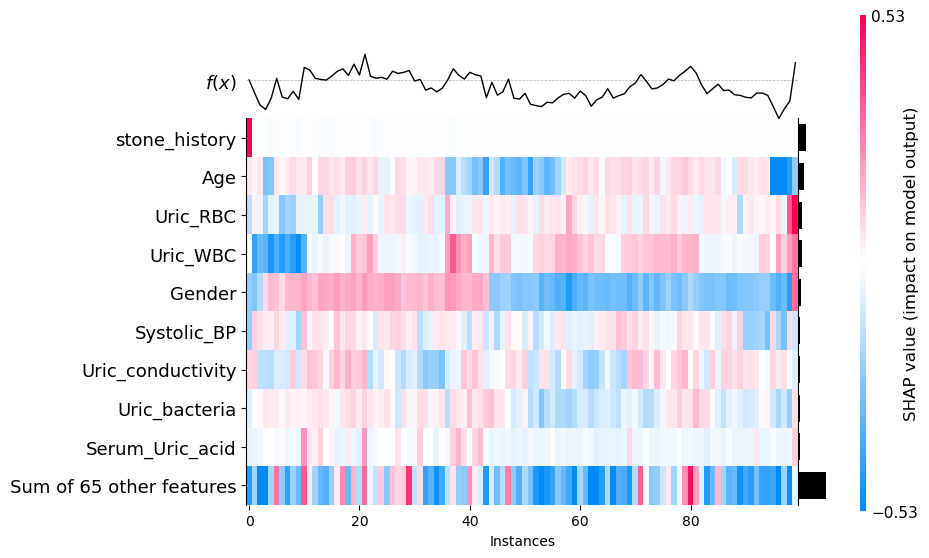

<Axes: xlabel='Instances'>

In [ ]:
# 更改排序顺序和全局特征重要性值 热图
shap.plots.heatmap(shap_values_train[:100], feature_values=shap_values_train[:100].abs.max(0))

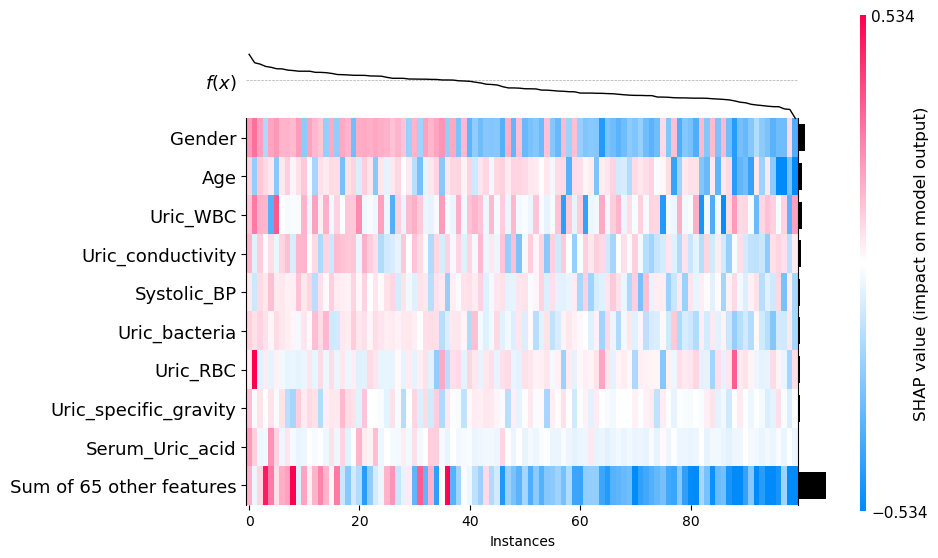

<Axes: xlabel='Instances'>

In [93]:
shap.plots.heatmap(shap_values_train[:100], instance_order=shap_values_train[:100].sum(1))

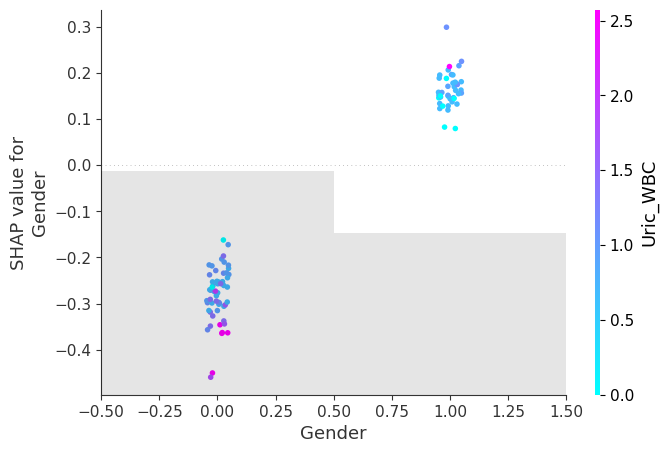

In [97]:
# https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/scatter.html

shap.plots.scatter(shap_values_train[:100][:, "Gender"], color=shap_values_train[:100],cmap=plt.get_cmap("cool"))

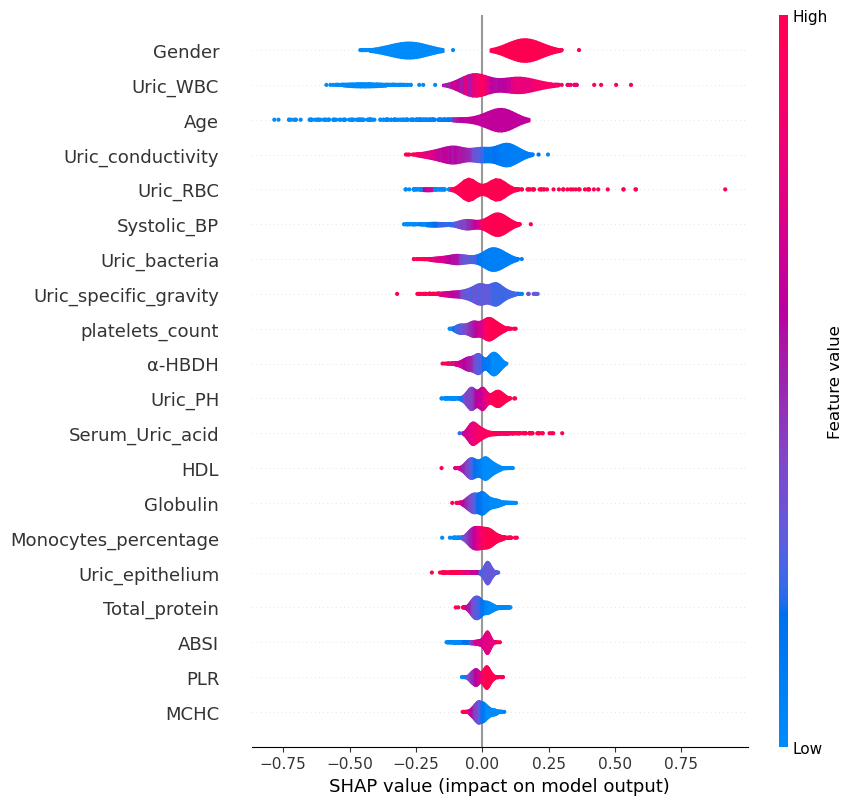

In [ ]:
#小弹琴图  不知道和最开始的蜂群图有什么大区别
# https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/violin.html
shap.plots.violin(shap_values_train[:1000], color="red")

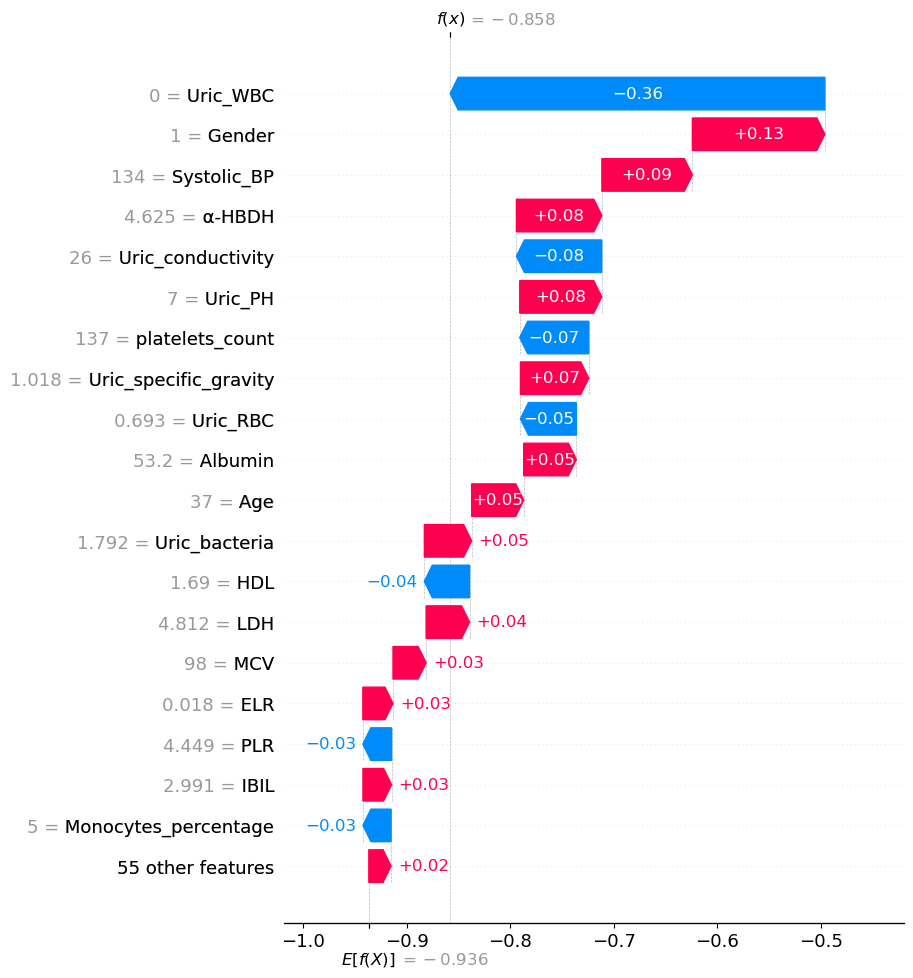

In [ ]:
# 瀑布图 单个样本分析
# https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html
shap.plots.waterfall(shap_values_train[0], max_display=20)

In [113]:
data_file_path = 'data_cleaned/ver-noelectrolyte-logtransform_mean.csv'
model_path = 'trained_models_opt/mean/LogisticRegression_0.67.pkl'
model = ehr_utils.load_model(model_path)
X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(data_file_path)
X_sample= X_train.sample(100, random_state=42)


In [ ]:
explainer_base = shap.Explainer(model)
explainer_tree = shap.TreeExplainer(model)

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: LogisticRegression(C=8.07, class_weight='balanced', random_state=42,
                   solver='liblinear')

In [115]:
shap_values_base = explainer_base(X_sample)
shap_values_tree = explainer_tree(X_sample)

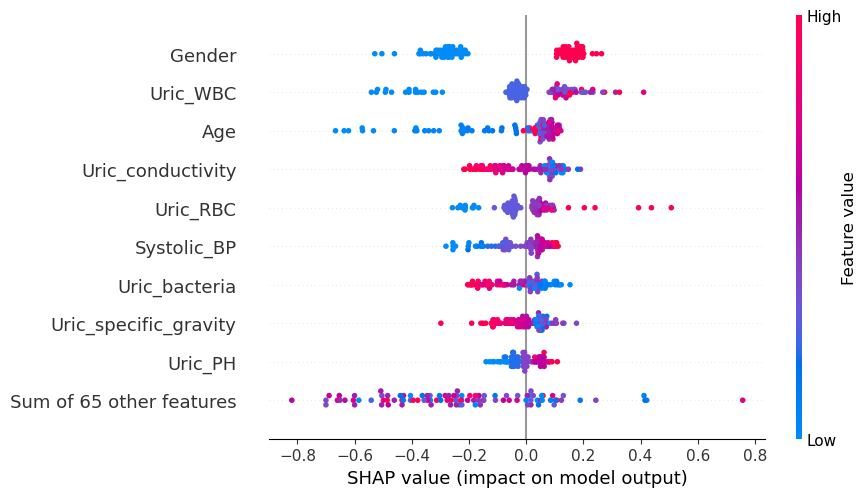

In [110]:
shap.plots.beeswarm(shap_values_base)

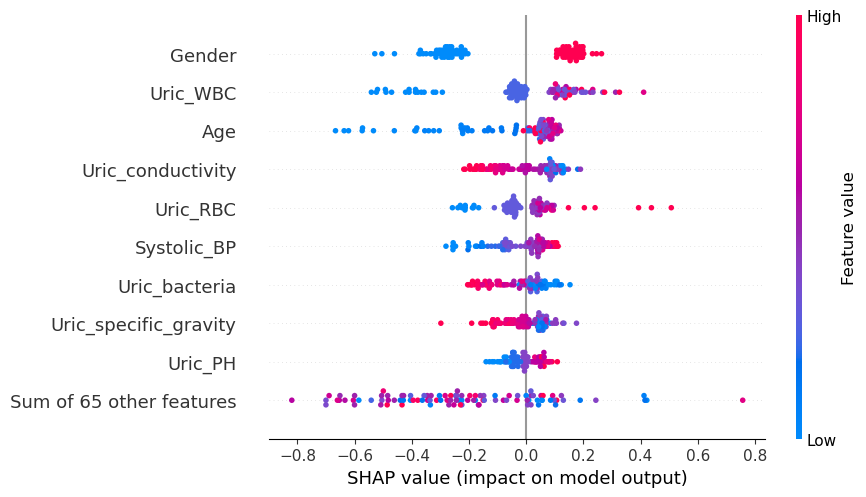

In [111]:
shap.plots.beeswarm(shap_values_tree)